Um modelo de regressão é uma linha que encontra o padrão nos dados e usa para fazer previsões! 
Prevendo valores de imóveis 📈

Na aula de hoje, vamos explorar um dataset que contém algumas características sobre imóveis, tais como area, andar, suites, vista, e entre outros atributos.

Nosso desafio de hoje será tentar encontrar uma forma de criar um algortimo preditivo que utilize essas características para predizer o valor do imóvel, será que é possível?

Atributos:

Ordem: Coluna de ID.
Valor: Valor do imóvel.
Area: Tamanho da área do imóvel.
IA: Idade do imóvel.
Andar: Quantidade de andares.
Suites: Quantidade de suítes.
Vista: Se o imóvel possúi uma boa vista ou não.
DistBM: Distancia do Imovel do Mar.
SemRuido: Se o imóvel é localizado em uma região calma ou não.
AV100m: DistPróximo à área verde.
Vamos começar a trabalhar com os dados!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
imoveis = pd.read_csv("Valorizacao_Ambiental.csv", sep=";")
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m
0,1,160000,168,1,5,1,1,294,1,0
1,2,67000,129,1,6,0,0,1505,1,0
2,3,190000,218,1,8,1,0,251,0,1
3,4,110000,180,12,4,1,0,245,0,0
4,5,70000,120,15,3,1,0,956,1,0


In [ ]:
imoveis.shape

(172, 10)

In [ ]:
#arredondando o número para duas casas decimais .round(2)
imoveis.describe().round(2)

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m
count,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00
mean,86.50,173541.95,163.20,5.65,4.30,1.40,0.14,505.89,0.58,0.35
std,49.80,99827.09,65.92,5.57,2.24,1.13,0.35,395.05,0.49,0.48
min,1.00,40000.00,69.00,1.00,1.00,0.00,0.00,73.00,0.00,0.00
25%,43.75,104750.00,117.00,1.00,2.75,1.00,0.00,214.75,0.00,0.00
50%,86.50,149000.00,145.00,2.50,4.00,1.00,0.00,402.50,1.00,0.00
75%,129.25,209250.00,182.00,11.00,6.00,2.00,0.00,638.00,1.00,1.00
max,172.00,579840.00,393.00,19.00,12.00,6.00,1.00,1859.00,1.00,1.00


In [ ]:
imoveis.info()

<class 'pandas.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Ordem     172 non-null    int64
 1   Valor     172 non-null    int64
 2   Area      172 non-null    int64
 3   IA        172 non-null    int64
 4   Andar     172 non-null    int64
 5   Suites    172 non-null    int64
 6   Vista     172 non-null    int64
 7   DistBM    172 non-null    int64
 8   Semruido  172 non-null    int64
 9   AV100m    172 non-null    int64
dtypes: int64(10)
memory usage: 13.6 KB


In [ ]:
#somando valores nulos
imoveis.isnull().sum()

Ordem       0
Valor       0
Area        0
IA          0
Andar       0
Suites      0
Vista       0
DistBM      0
Semruido    0
AV100m      0
dtype: int64

In [ ]:
#somando valores não nulos
imoveis.notnull().sum()

Ordem       172
Valor       172
Area        172
IA          172
Andar       172
Suites      172
Vista       172
DistBM      172
Semruido    172
AV100m      172
dtype: int64

Identificando a variável target

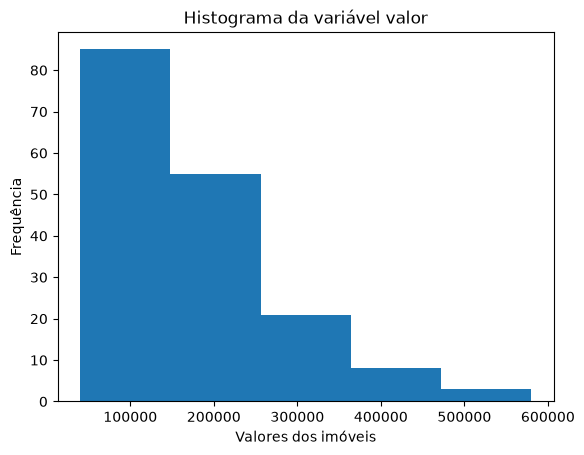

In [ ]:
plt.hist(imoveis["Valor"], bins = 5)  #bins significa a quantidade de colunas e a frequencia 
plt.ylabel("Frequência")
plt.xlabel("Valores dos imóveis")
plt.title("Histograma da variável valor")
plt.show()

In [ ]:
#criando nova coluna com raiz quadrada
imoveis["raiz_valor"] = np.sqrt(imoveis["Valor"])
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m,raiz_valor
0,1,160000,168,1,5,1,1,294,1,0,400.000000
1,2,67000,129,1,6,0,0,1505,1,0,258.843582
2,3,190000,218,1,8,1,0,251,0,1,435.889894
3,4,110000,180,12,4,1,0,245,0,0,331.662479
4,5,70000,120,15,3,1,0,956,1,0,264.575131


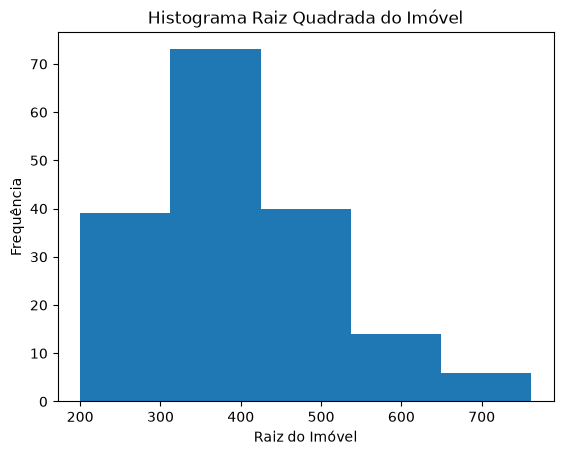

In [ ]:
plt.hist(imoveis['raiz_valor'], bins = 5)
plt.xlabel("Raiz do Imóvel")
plt.ylabel("Frequência")
plt.title("Histograma Raiz Quadrada do Imóvel")
plt.show()

Lapidando variaveis do imóvel

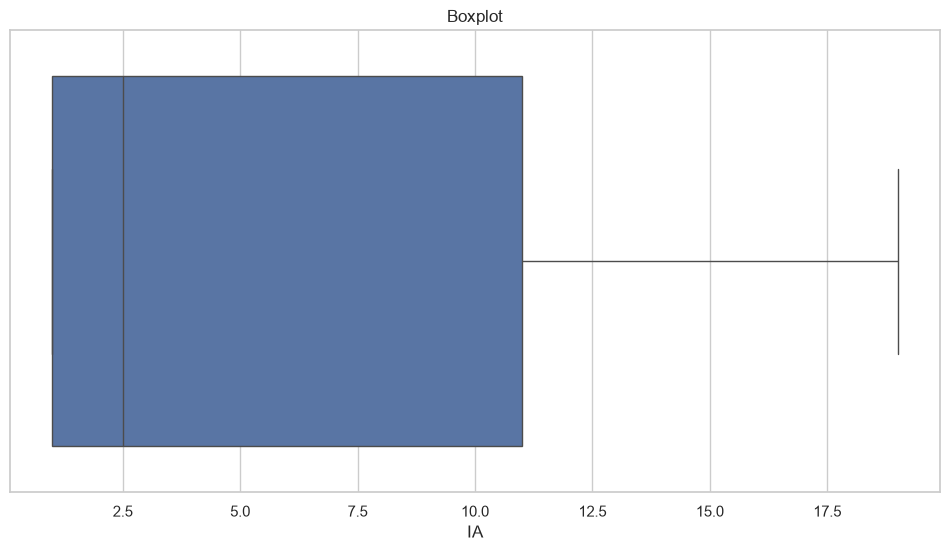

In [ ]:
#criando boxplot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(figsize=(12,6))
sns.boxplot(x = "IA", data = imoveis)
axes.set_title("Boxplot")
plt.show()


Text(0, 0.5, 'Qtd Suites')

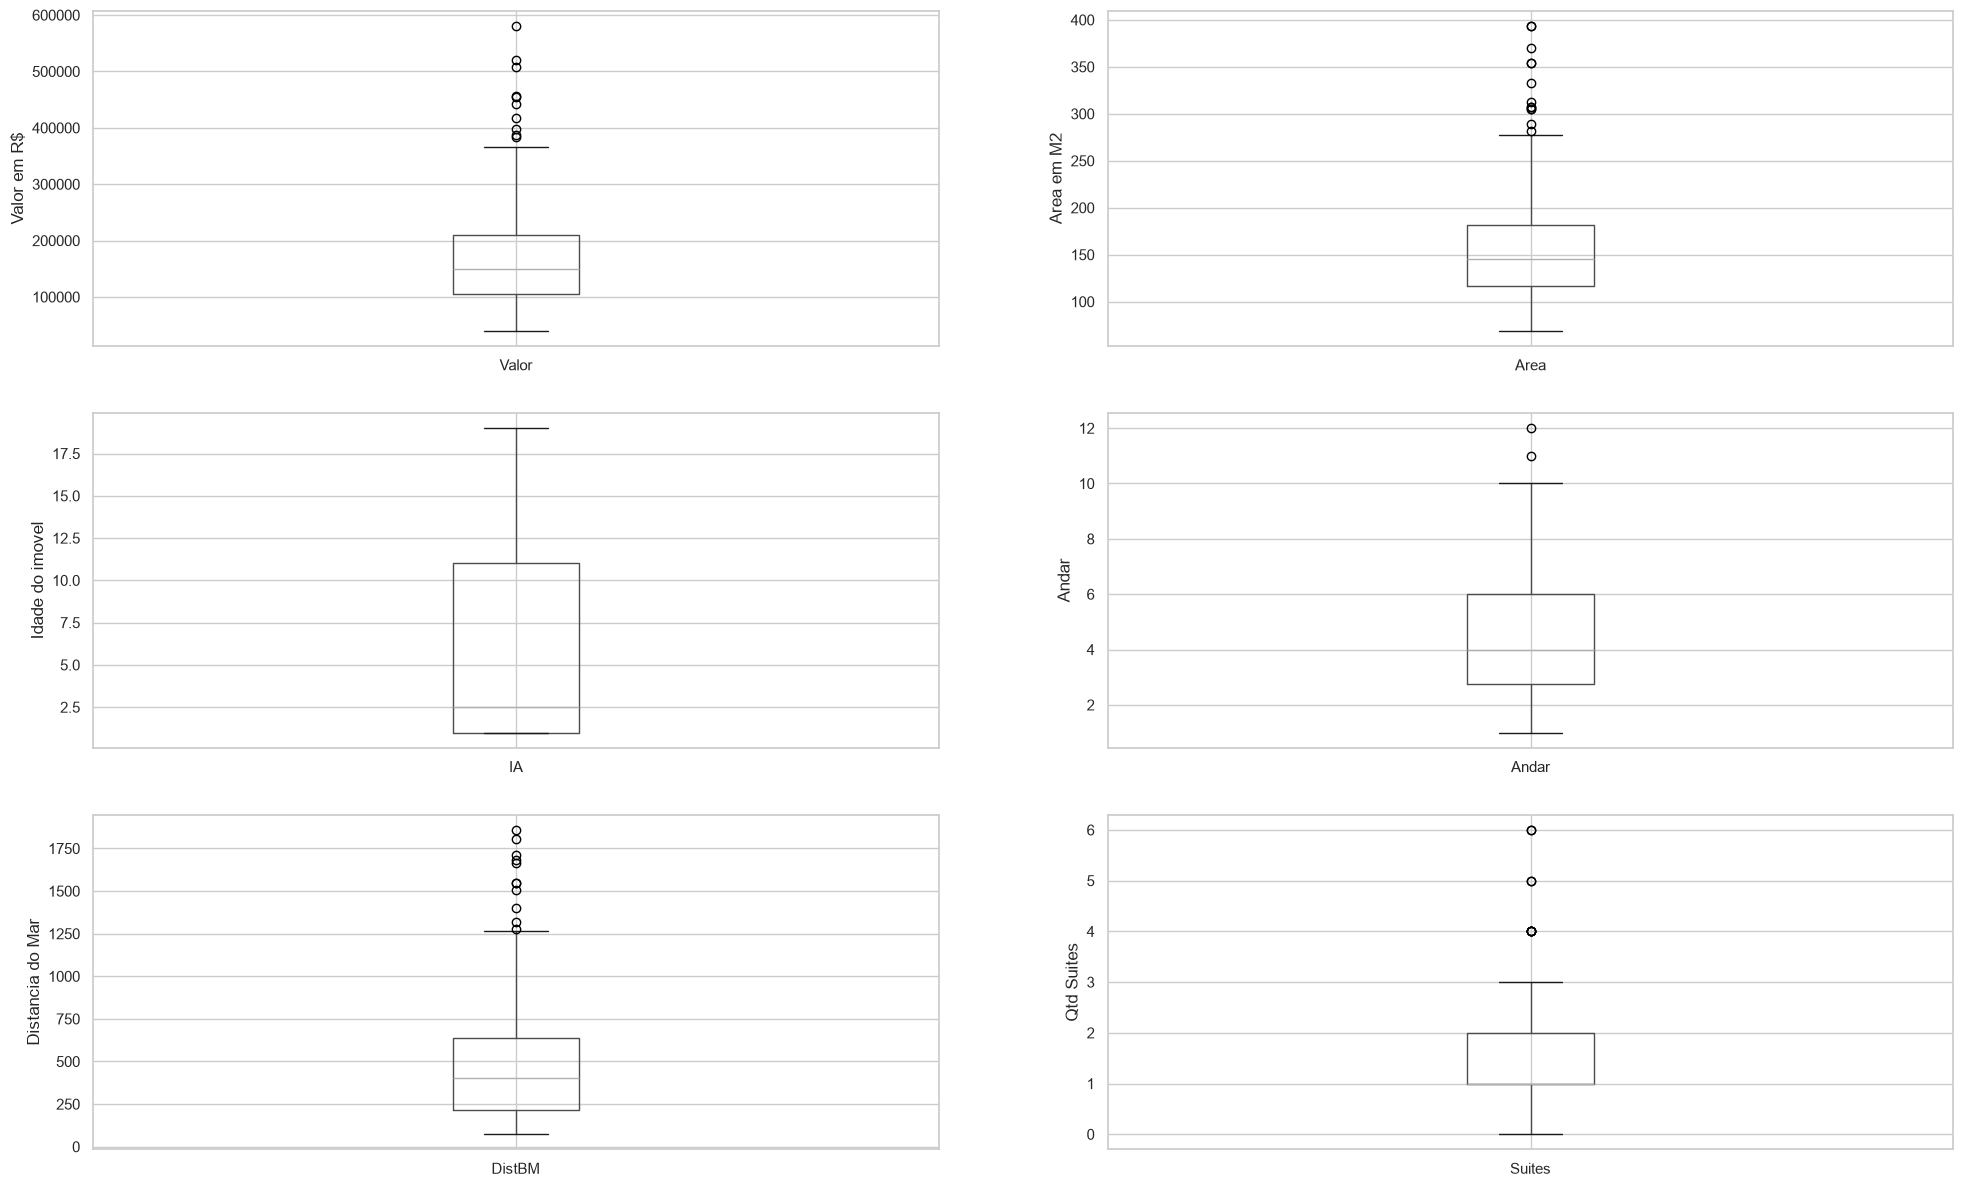

In [ ]:
# criando 3 boxplots juntos, a variacao corre dentro da variavel de subplot
plt.figure(figsize=(24,20))

plt.subplot(4,2,1)
fig = imoveis.boxplot(column = "Valor")
fig.set_title("")
fig.set_ylabel("Valor em R$")


plt.subplot(4,2,2)
fig = imoveis.boxplot(column = "Area")
fig.set_title("")
fig.set_ylabel("Area em M2")


plt.subplot(4,2,3)
fig = imoveis.boxplot(column = "IA")
fig.set_title("")
fig.set_ylabel("Idade do imovel")

plt.subplot(4,2,4)
fig = imoveis.boxplot(column = "Andar")
fig.set_title("")
fig.set_ylabel("Andar")

plt.subplot(4,2,5)
fig = imoveis.boxplot(column = "DistBM")
fig.set_title("")
fig.set_ylabel("Distancia do Mar")

plt.subplot(4,2,6)
fig = imoveis.boxplot(column = "Suites")
fig.set_title("")
fig.set_ylabel("Qtd Suites")



#CAIXA (quadrado) = 50% dos dados concentrados
#LINHA dentro = Mediana (valor do meio)
#TRAÇO de cima = Até onde vai o maior valor "normal"
# TRAÇO de baixo = Até onde vai o menor valor "normal"
#PONTOS acima =Outliers (valores muito diferentes)




MATRIZ DE CORRELAÇÃO ( quanto mais proximo de 1 maior correlação dos dados)

<Axes: >

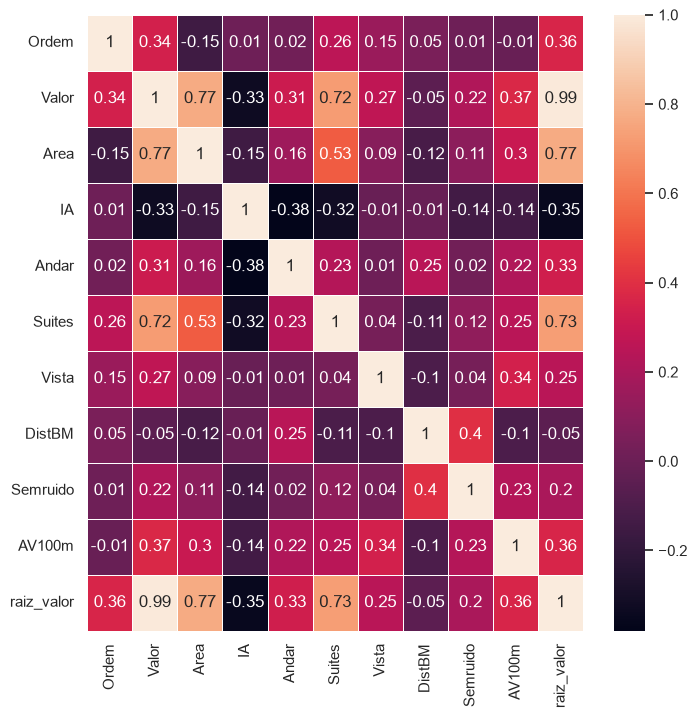

In [ ]:
correlation_matrix = imoveis.corr().round(2)
fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)



Text(0.5, 1.0, 'área do imóvel x valor')

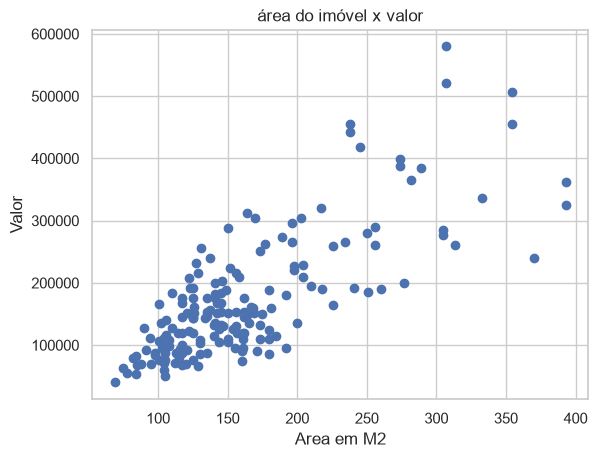

In [ ]:
#Grafico de dispersão
plt.scatter("Area","Valor", data =imoveis)
plt.xlabel ("Area em M2")
plt.ylabel("Valor")
plt.title("área do imóvel x valor")

# quanto menor o M2 menor o valor

Text(0.5, 1.0, 'Qtd de Suites x valor')

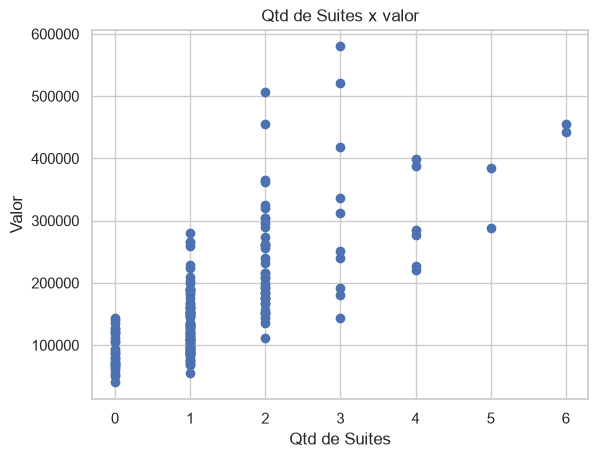

In [ ]:
#valor x suites

plt.scatter("Suites", "Valor", data= imoveis) 
plt.xlabel ("Qtd de Suites")
plt.ylabel("Valor")
plt.title("Qtd de Suites x valor")


Variaveis sem correlação

Text(0.5, 1.0, 'Idade Imóvel x valor')

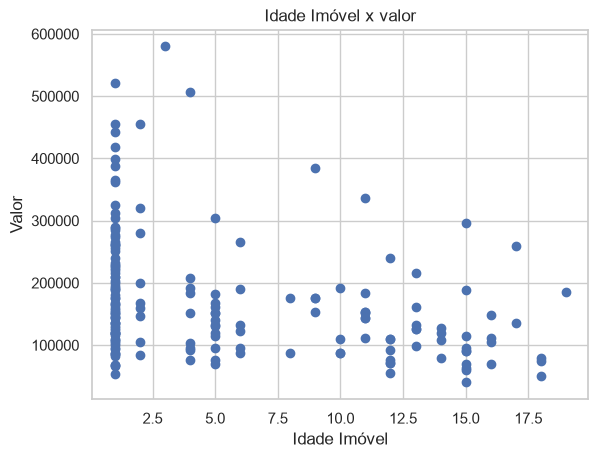

In [ ]:
#IA - Não variavel crescendo de forma linear ( não é necessariamente uma coisa ruim ) - a idade do valor não esta interferindo no valor do imóvel
#Não utilizaremos no modelo

plt.scatter("IA", "Valor", data= imoveis) 
plt.xlabel ("Idade Imóvel")
plt.ylabel("Valor")
plt.title("Idade Imóvel x valor")

In [ ]:
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m,raiz_valor
0,1,160000,168,1,5,1,1,294,1,0,400.000000
1,2,67000,129,1,6,0,0,1505,1,0,258.843582
2,3,190000,218,1,8,1,0,251,0,1,435.889894
3,4,110000,180,12,4,1,0,245,0,0,331.662479
4,5,70000,120,15,3,1,0,956,1,0,264.575131


C:\Users\barre\AppData\Local\Temp\ipykernel_2076\1433544956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="Vista", y="Valor", data = imoveis, palette = "Set2")


<Axes: xlabel='Vista', ylabel='Valor'>

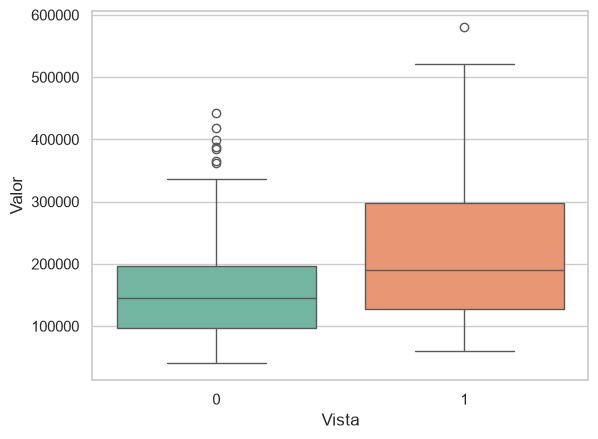

In [ ]:
# IMÓVEIS COM VISTA PARA O MAR TEM VALOR MAIS ALTO

import seaborn as sb
sb.boxplot(x="Vista", y="Valor", data = imoveis, palette = "Set2")

C:\Users\barre\AppData\Local\Temp\ipykernel_2076\2545530415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="Semruido", y="Valor", data = imoveis, palette = "Set2")


<Axes: xlabel='Semruido', ylabel='Valor'>

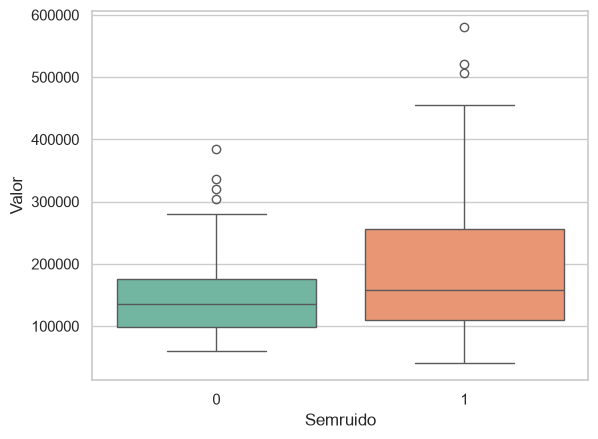

In [ ]:
#verificando valores de imóveis com e sem ruído, para ver se há diferença de valor entre eles
sb.boxplot(x="Semruido", y="Valor", data = imoveis, palette = "Set2")

C:\Users\barre\AppData\Local\Temp\ipykernel_2076\755384190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="AV100m", y="Valor", data = imoveis, palette = "Set2")


<Axes: xlabel='AV100m', ylabel='Valor'>

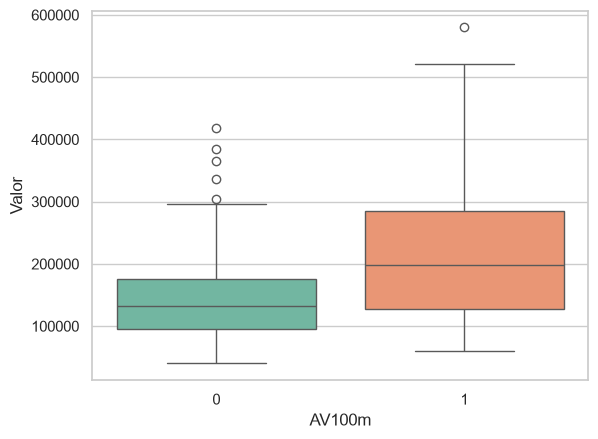

In [ ]:
# Imovéis próximos de área verde possuem valor mais alto 
sb.boxplot(x="AV100m", y="Valor", data = imoveis, palette = "Set2")

REGRESSÃO LINEAR -----------------------------------------


1. Treinar → lr.fit(X_train, y_train)
2. Prever → y_pred = lr.predict(X_test)
3. Comparar → y_pred vs y_test (valores reais)
4. Avaliar → Calcular erro/acurácia

In [ ]:
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m,raiz_valor
0,1,160000,168,1,5,1,1,294,1,0,400.000000
1,2,67000,129,1,6,0,0,1505,1,0,258.843582
2,3,190000,218,1,8,1,0,251,0,1,435.889894
3,4,110000,180,12,4,1,0,245,0,0,331.662479
4,5,70000,120,15,3,1,0,956,1,0,264.575131


In [ ]:
#Regressão linear múltipla

from sklearn.linear_model import LinearRegression

#criando um objeto de Regressão Linear
lr = LinearRegression()

In [ ]:
# X contem as váriaveis independentes (preditoras)
X = imoveis[['Area', 'Suites', 'IA', 'Semruido', 'Vista', 'Andar', 'AV100m', 'DistBM']]


#  y a variável dependente (resposta)
y = imoveis[['Valor']]

In [ ]:
X

,Area,Suites,IA,Semruido,Vista,Andar,AV100m,DistBM
0,168,1,1,1,1,5,0,294
1,129,0,1,1,0,6,0,1505
2,218,1,1,0,0,8,1,251
3,180,1,12,0,0,4,0,245
4,120,1,15,1,0,3,0,956
...,...,...,...,...,...,...,...,...
167,82,0,14,1,0,2,0,485
168,134,0,11,1,1,2,1,827
169,135,2,9,1,1,3,1,414
170,141,2,1,0,0,6,0,305


In [ ]:
y

,Valor
0,160000
1,67000
2,190000
3,110000
4,70000
...,...
167,80000
168,144000
169,176000
170,199956


In [ ]:
#preciso utilizar --- Padrão

from sklearn.model_selection import train_test_split

#Separando os dados em treino e teste, 20% dos dados serão para teste e 80% para treino
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
#Treinando o Modelo

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 8)","[[ 775.52,35421.93,-1216.4 ,..., 5177.62, 2993.79, 5.83]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Area','Suites','IA',...,'Andar','AV100m','DistBM']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-40070.76]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


X_test: dados de teste (sem os rótulos conhecidos)
lr.predict(): o modelo usa o que aprendeu para prever os valores
y_pred: armazena as predições do modelo ---Valor predito é a resposta que o modelo dá. É o que o modelo acha que é a resposta correta.

In [ ]:
# Calculando o valor predito da varável resposta na amostra teste
#Valor predito é a resposta que o modelo dá. É o que o modelo acha que é a resposta correta.
y_pred = lr.predict(X_test)

In [ ]:
#Primeiro, vamos olhar o Intercepto e os coeficientes do modelo, que são os pesos das variáveis independentes.
# Representa o valor esperado da variavel dependente quando todas as variasveis independentes são iguais a zero.
# em termos gráficos, o intercepto é o ponto onde a linha de regressão cruza o eixo vertical (Y)
 
print('Intercepto: ', lr.intercept_)

Intercepto:  [-40070.75559259]


In [ ]:
# Os coeficiente da regressão linear representam as inclinações da linha de regressão para cada variavel
coefficientes = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(lr.coef_))], axis=1)
coefficientes

,0,0
0,Area,775.516295
1,Suites,35421.934260
2,IA,-1216.396527
3,Semruido,16761.218088
4,Vista,51079.523129
5,Andar,5177.619283
6,AV100m,2993.793699
7,DistBM,5.832360


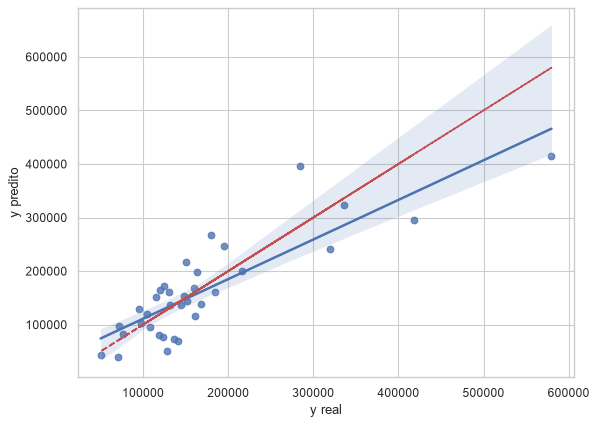

In [ ]:
fig = plt.figure(figsize=(8,6), dpi = 80)
plt.rcParams.update({'font.size' : 14 })
ax = sb.regplot( x = y_test, y = y_pred)
ax.set(xlabel = 'y real', ylabel = 'y predito')
ax = plt.plot(y_test, y_test, '--r')
plt.show()




#Pontos azuis =	Cada predição que o modelo fez
#Linha azul =	Tendência geral do modelo
#Faixa azul clara	= Intervalo de confiança (incerteza)
#Linha vermelha tracejada	= Perfeição (onde y_pred = y_real)

SOBRE OS ERROS DO MODELO --- Não existe modelo perfeito! se ele sempre acerta não precisa do modelo ---- ele vira overfiting ( decorou as coisas)

In [ ]:
#Avaliando o modelo (FOI BOM)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


MAE  = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE: ", MAE)  # Mean Absolute Error (Erro médio absoluto) - Quanto maior o valor, pior o modelo. Quanto menor o valor, melhor o modelo.
print("MSE: ", MSE)  # Mean Squared Error (Erro médio quadrático) - Quanto maior o valor, pior o modelo. Quanto menor o valor, melhor o modelo.
print("R2: ", r2)    # R² (Coeficiente de determinação) - Quanto mais próximo de 1, melhor o modelo.

MAE:  42058.330268409176
MSE:  3129738139.073979
R2:  0.7107448551899099


MODELO DecisionTreeRegressor (arvore de decisão)- é legal comparar o comportamento com outros modelos para realizar comparação

In [ ]:
from sklearn.tree import DecisionTreeRegressor

#Criando o modelo de Decision Tree Regressor
model_dtr = DecisionTreeRegressor( random_state=101, max_depth = 10) #max_depth = quant de ramificação tunando o modelo
model_dtr.fit(X_train, y_train)



,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",101
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [ ]:
y_pred_model_dtr = model_dtr.predict(X_test)

In [ ]:
#Avaliando o modelo (FOI RUIM)
MAE = mean_absolute_error(y_test, y_pred_model_dtr)
MSE = mean_squared_error(y_test, y_pred_model_dtr)
R2 = r2_score(y_test, y_pred_model_dtr)
print("MAE: ", MAE)  # Mean Absolute Error (Erro médio absoluto) - Quanto maior o valor, pior o modelo. Quanto menor o valor, melhor o modelo.
print("MSE: ", MSE)  # Mean Squared Error (Erro médio quadrático) - Quanto maior o valor, pior o modelo. Quanto menor o valor, melhor o modelo.   
print("R2: ", R2)    # R² (Coeficiente de determinação) - Quanto mais próximo de 1, melhor o modelo.PR  



MAE:  54263.64761904762
MSE:  5291269556.593651
R2:  0.5109728437937089


AVALIANDO COM SVR ---- Support Vector Regression, usado para tarefas de regressão, em que a tarefa é prever um valor contínuo em vez de uma classe

In [ ]:
from sklearn.svm import SVR

In [ ]:
#criando o modelo de SVM
svr = SVR(kernel = 'linear')


In [ ]:
svr.fit(X_train, y_train)

c:\Users\barre\OneDrive\Documentos\Laura - FIAP\Fase -2\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [ ]:
y_pred_svr = svr.predict(X_test)

In [ ]:
#Avaliando o modelo (FOI RUIM)
MAE = mean_absolute_error(y_test, y_pred_svr)
MSE = mean_squared_error(y_test, y_pred_svr)
R2 = r2_score(y_test, y_pred_svr)
print("MAE: ", MAE)  # Mean Absolute Error (Erro médio absoluto) - Quanto maior o valor, pior o modelo. Quanto menor o valor, melhor o modelo.
print("MSE: ", MSE)  # Mean Squared Error (Erro médio quadrático) - Quanto maior o valor, pior o modelo. Quanto menor o valor, melhor o modelo.   
print("R2: ", R2)    # R² (Coeficiente de determinação) - Quanto mais próximo de 1, melhor o modelo.PR  

MAE:  44753.273835698645
MSE:  4753087377.153741
R2:  0.5607124569276567
